In [1]:
import pandas as pd
import numpy as np

In [2]:
train=pd.read_csv('/Users/piyushagarwal/Documents/3rd YR AI MSE1/train.csv')

In [3]:
train.head()

,Temperature Anomaly,Wind Speed Variation,Industrial Emission Index,Traffic Density Score,Change in AQI
0,0.891,0.899,-0.749,-0.933,-31.15
1,NaN,0.275,NaN,0.011,141.55
2,0.253,NaN,-1.725,0.405,NaN
3,-0.505,-0.768,-1.474,0.422,-145.55
4,0.693,1.019,NaN,1.538,167.65


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature Anomaly        669 non-null    float64
 1   Wind Speed Variation       630 non-null    float64
 2   Industrial Emission Index  640 non-null    float64
 3   Traffic Density Score      651 non-null    float64
 4   Change in AQI              686 non-null    float64
dtypes: float64(5)
memory usage: 28.8 KB


In [5]:
train.drop_duplicates(inplace=True)

In [6]:
train.duplicated().sum()

0

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

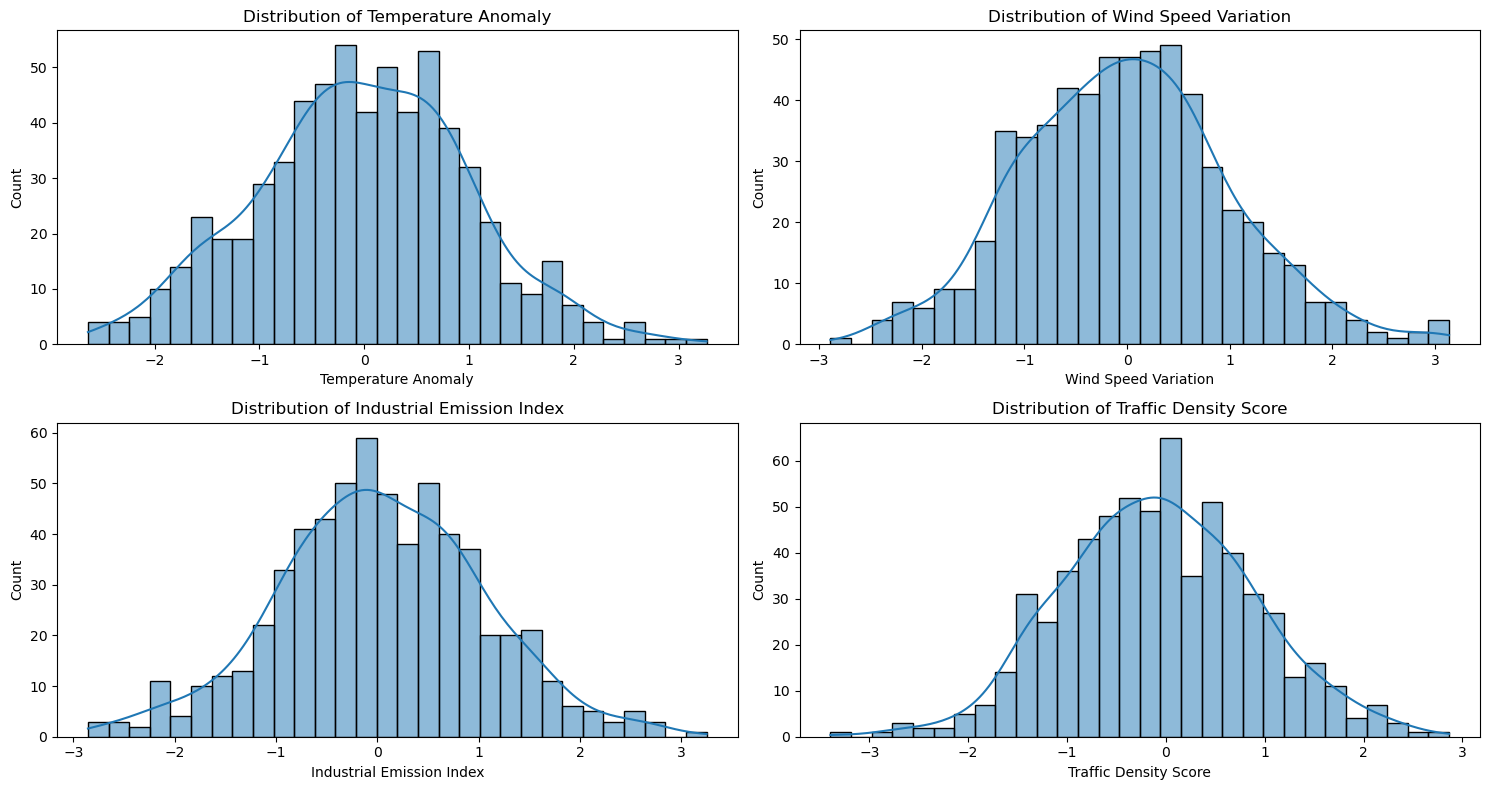

In [8]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(train.columns[:-1]):  # exclude target
    plt.subplot(2, (3+1)//2, i+1)
    sns.histplot(train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

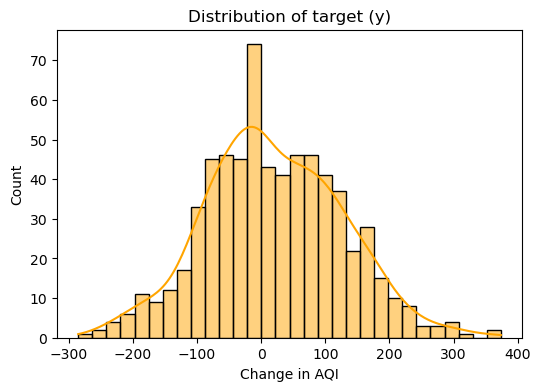

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(train['Change in AQI'], kde=True, bins=30, color='orange')
plt.title("Distribution of target (y)")
plt.show()

In [10]:
train['Temperature Anomaly'] = train['Temperature Anomaly'].fillna(train['Temperature Anomaly'].median())
train['Wind Speed Variation'] = train['Wind Speed Variation'].fillna(train['Wind Speed Variation'].mean())
train['Industrial Emission Index'] = train['Industrial Emission Index'].fillna(train['Industrial Emission Index'].mean())
train['Traffic Density Score'] = train['Traffic Density Score'].fillna(train['Traffic Density Score'].mean())
train['Change in AQI'] = train['Change in AQI'].fillna(train['Change in AQI'].mean())

In [11]:
train.describe()

,Temperature Anomaly,Wind Speed Variation,Industrial Emission Index,Traffic Density Score,Change in AQI
count,700.000000,700.000000,700.000000,700.000000,700.000000
mean,-0.021023,-0.015795,0.031751,-0.084513,19.819771
std,0.966135,0.933126,0.947991,0.907912,103.689287
min,-2.636000,-2.888000,-2.857000,-3.394000,-285.350000
25%,-0.585000,-0.592250,-0.552000,-0.653000,-49.550000
50%,-0.018000,-0.015795,0.031751,-0.084513,19.819771
75%,0.599000,0.485500,0.589000,0.473000,87.400000
max,3.266000,3.135000,3.250000,2.865000,373.850000


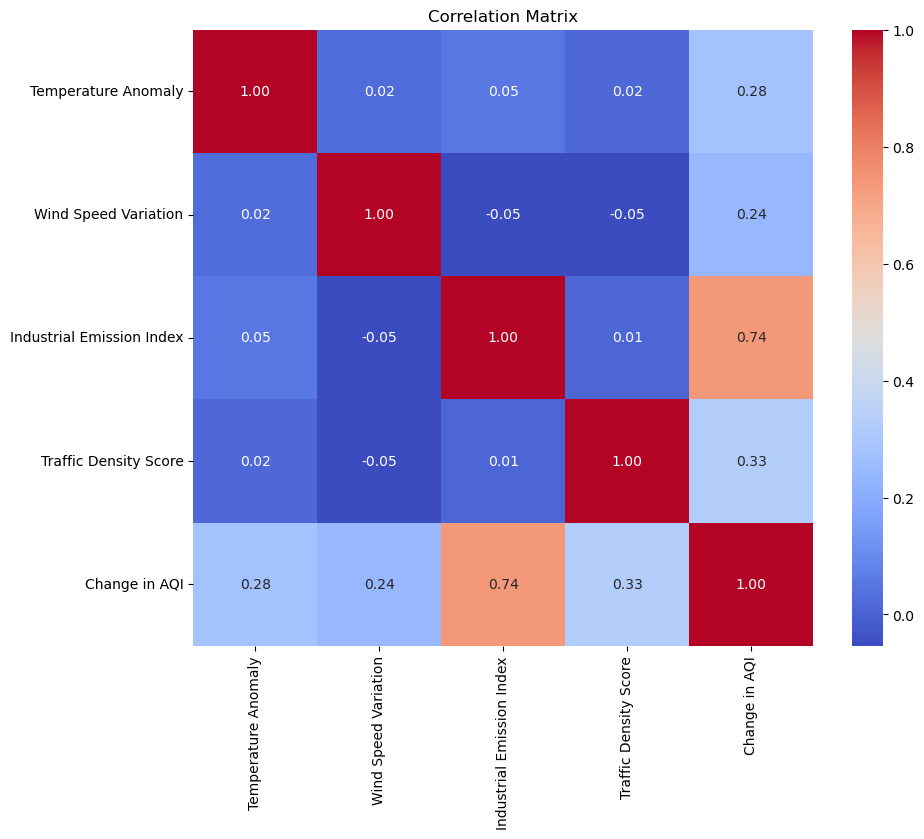

In [12]:
plt.figure(figsize=(10, 8))
corr = train.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [15]:
X = train.drop('Change in AQI', axis=1)
y = train['Change in AQI']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

print("Linear Regression R2:", r2_score(y_val, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_val, y_pred_lr))

Linear Regression R2: 0.7274277388230715
Linear Regression MSE: 2337.177015646455


In [17]:
df_test=pd.read_csv('/Users/piyushagarwal/Documents/3rd YR AI MSE1/test.csv')

In [18]:
df_test.head()

,id,Temperature Anomaly,Wind Speed Variation,Industrial Emission Index,Traffic Density Score
0,1,0.892,-0.956,0.719,-0.637
1,2,-0.497,-1.701,-0.383,-0.428
2,3,-0.282,-2.140,0.834,0.960
3,4,-0.231,-0.562,0.029,0.626
4,5,0.406,-0.579,-1.115,0.517


In [19]:
test=df_test.drop(columns=['id'])

In [20]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature Anomaly        300 non-null    float64
 1   Wind Speed Variation       300 non-null    float64
 2   Industrial Emission Index  300 non-null    float64
 3   Traffic Density Score      300 non-null    float64
dtypes: float64(4)
memory usage: 9.5 KB


In [21]:
y_pred = lr.predict(test)

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [22]:
new_df = pd.DataFrame({
    'id': df_test['id'],
    'Change in AQI': y_pred
})


In [23]:
new_df.to_csv('sandbox.csv', index=False)